In [5]:
from pathlib import Path
import pymatgen.analysis.solar.slme as slme
import numpy as np
    
def calc_slme(energy, absorption, eg_dir, eg_indir):
    thickness = np.logspace(-8, -4, 100, endpoint=True)
    thickness_nm = thickness * 1e9
    slmes = []
    for i in thickness:
        val = slme.slme(
            energy,
            absorption,
            eg_dir,
            eg_indir,
            thickness=i,
            absorbance_in_inverse_centimeters=True
        )
        slmes.append(val)
    return thickness_nm, slmes

BASE_PATH = Path("../")


systems = {
    "HzZrS3": {
        "dir_eg": 1.848, 
        "indir_eg": 1.734, 
        "tilt": 8.85,
        "colour": "C0",
        "folder": "01_hzzrs3",
    },
    "HzZrSe3": {
        "dir_eg": 1.359, 
        "indir_eg": 1.306,
        "tilt": 10.95,
        "colour": "C1",
        "folder": "02_hzzrse3",
    },
    "HzHfS3": {
        "dir_eg": 2.106, 
        "indir_eg": 1.962,
        "tilt": 8.85,
        "colour": "C2",
        "folder": "03_hzhfs3",
    },
    "HzHfSe3": {
        "dir_eg": 1.628, 
        "indir_eg": 1.519,
        "tilt": 10.65,
        "colour": "C3",
        "folder": "04_hzhfse3",
    },
}

absorption_data = {}
for system_name, folder in systems.items():
    energy, absorption = np.loadtxt(BASE_PATH / folder["folder"] / "optics-hse"/ "absorption.dat", skiprows=1).T
    thickness_nm, slmes = calc_slme(
        energy,
        absorption,
        folder["dir_eg"],
        folder["indir_eg"]
    )
    absorption_data[system_name] = {
        "energy": energy,
        "absorption": absorption,
        "thickness_nm": thickness_nm,
        "slme": slmes
    }


HzZrSe3
HzHfSe3
HzZrS3
HzHfS3


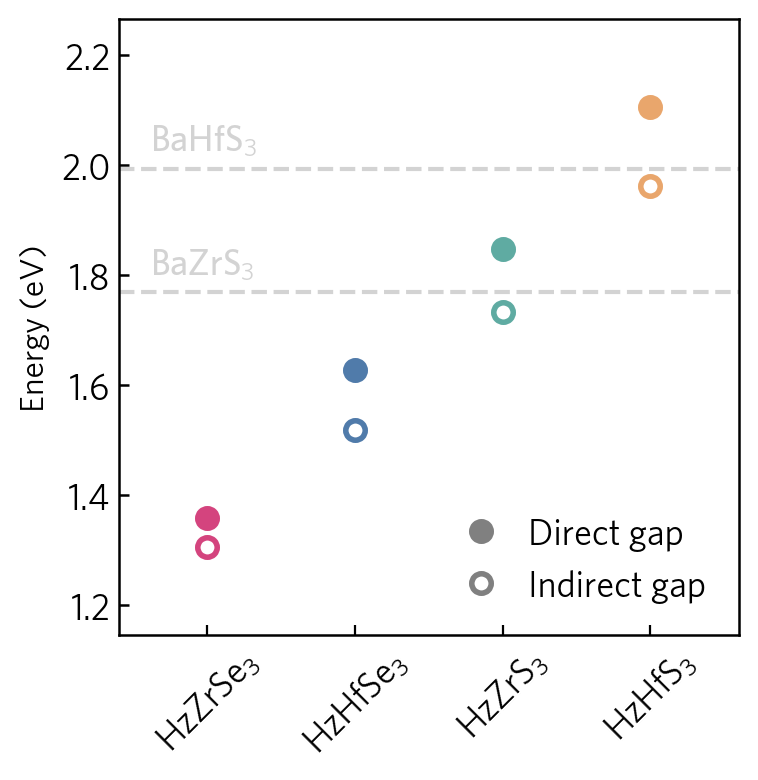

In [6]:
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

plt.style.use(["style.mplstyle"])

def plot_bandgap(ax):
    order = sorted(systems.keys(), key=lambda x: systems[x]["dir_eg"])
    for i, name in enumerate(order):
        print(name)
        ax.plot(i, systems[name]["dir_eg"], "o", markerfacecolor=systems[name]["colour"], markeredgecolor=systems[name]["colour"], markersize=7, markeredgewidth=2)
        ax.plot(i, systems[name]["indir_eg"], "o", markerfacecolor=f"w", markeredgecolor=systems[name]["colour"], markersize=7, markeredgewidth=2)


    # add fake legend for direct and indirect bandgap
    ax.plot([], [], "o", markerfacecolor="grey", markeredgecolor="grey", markersize=7, markeredgewidth=2, label="Direct gap")
    ax.plot([], [], "o", markerfacecolor=f"w", markeredgecolor="grey", markersize=7, markeredgewidth=2, label="Indirect gap")
    ax.legend(loc="lower right", frameon=False)

    bazrs3_colour = "lightgray"    
    ax.text(0.05, 1.77 * 1.01, "BaZrS$_3$", color=bazrs3_colour, transform=blended_transform_factory(ax.transAxes, ax.transData), ha="left", va="bottom", fontweight="medium")
    ax.axhline(1.77, color=bazrs3_colour, ls="--")

    ax.text(0.05, 1.993 * 1.01, "BaHfS$_3$", color=bazrs3_colour, transform=blended_transform_factory(ax.transAxes, ax.transData), ha="left", va="bottom", fontweight="medium")
    ax.axhline(1.993, color=bazrs3_colour, ls="--")

    ax.set(ylabel="Energy (eV)")
    ax.set_xticks([i for i in range(len(order))])
    ax.set_xticklabels([system_name.replace("3", "$_3$") for system_name in order], rotation=45, ha="center")
    ax.margins(x=0.2, y=0.2)

fig, ax = plt.subplots(figsize=(4,4))
plot_bandgap(ax)

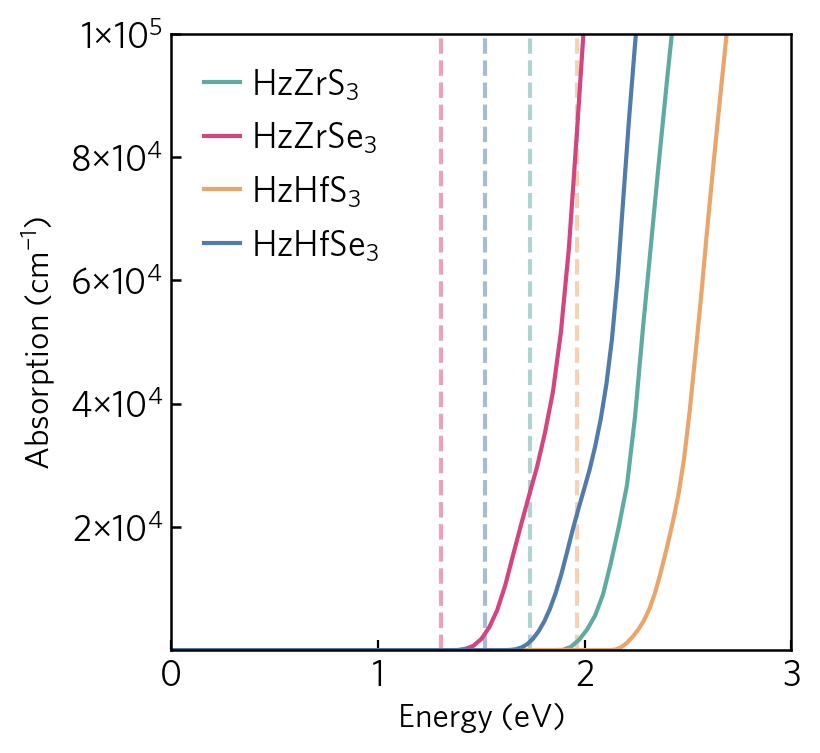

In [9]:
def plot_absorption(ax):
    for system_name, data in absorption_data.items():
        label = system_name.replace("3", "$_3$")
        ax.plot(data["energy"], data["absorption"], label=label)
        ax.axvline(systems[system_name]["indir_eg"], color=systems[system_name]["colour"], ls="--", zorder=-1, alpha=0.5)
    ax.set(
        xlabel="Energy (eV)",
        ylabel="Absorption (cm$^{-1}$)",
        xlim=(0, 3),
        ylim=(0, 1e5)
    )
    ax.legend(handlelength=1, handletextpad=0.3)
    ax.set_yticks([2e4, 4e4, 6e4, 8e4, 1e5])
    ax.set_yticklabels([r"2$\times$10$^{4}$", r"4$\times$10$^{4}$", r"6$\times$10$^{4}$", r"8$\times$10$^{4}$", r"1$\times$10$^{5}$"])

fig, ax = plt.subplots(figsize=(4,4))
plot_absorption(ax)

SLME at 200 nm:
HzZrS3: 16.93 %
HzZrSe3: 24.51 %
HzHfS3: 12.41 %
HzHfSe3: 19.97 %


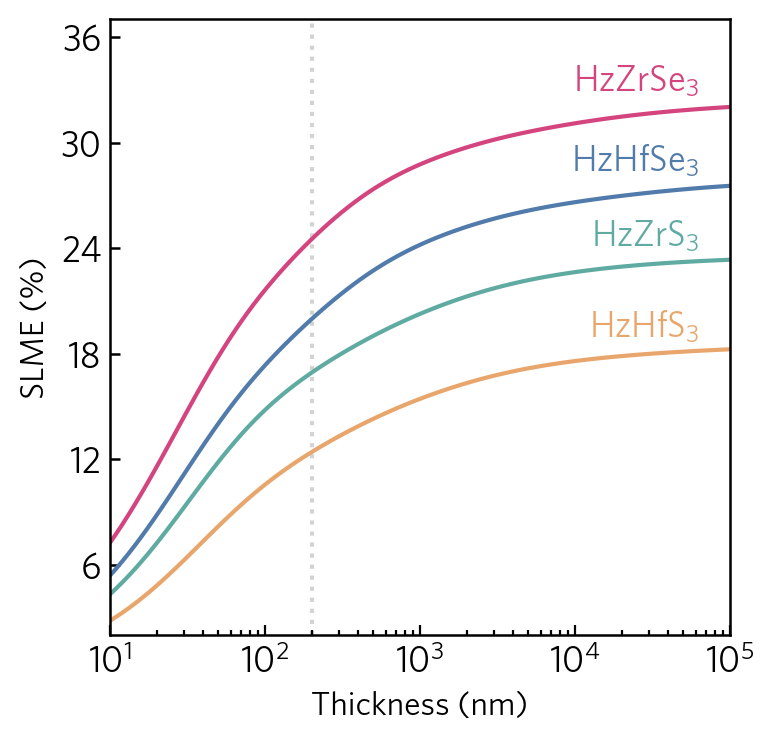

In [9]:
from matplotlib import transforms
from matplotlib.ticker import MaxNLocator

def plot_slme(ax):
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    slme_at_200 = {}
    for i, (system_name, data) in enumerate(absorption_data.items()):
        label = system_name.replace("3", "$_3$")
        ax.plot(data["thickness_nm"], data["slme"], label=label)
        
        t = np.asarray(data["thickness_nm"])
        y = np.asarray(data["slme"])
        slme_200 = np.interp(np.log10(200.0), np.log10(t), y)
        slme_at_200[system_name] = slme_200
        
        max_slme = data["slme"][-1]
        ax.text(0.95, max_slme * 1.015, label, transform=trans, ha="right", va="bottom", color=f"C{i}")
        
    print("SLME at 200 nm:")
    for k, v in slme_at_200.items():
        print(f"{k}: {v:.2f} %")
    
    ax.set(
        xlabel="Thickness (nm)",
        ylabel="SLME (%)",
        xscale="log",
        xlim=(10, 1e5),
        ylim=(2, 37)
    )
    ax.axvline(200, color="lightgray", ls=":", zorder=-5)
    ax.semilogx()
    ax.yaxis.set_major_locator(MaxNLocator(6))
    # place ticks at 10^1, 10^2, 10^3, 10^4, 10^5
    ax.set_xticks([10, 100, 1000, 10000, 100000])
    ax.set_xticklabels([r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$"])

fig, ax = plt.subplots(figsize=(4,4))
plot_slme(ax)

HzZrSe3
HzHfSe3
HzZrS3
HzHfS3
SLME at 200 nm:
HzZrS3: 16.93 %
HzZrSe3: 24.51 %
HzHfS3: 12.41 %
HzHfSe3: 19.97 %


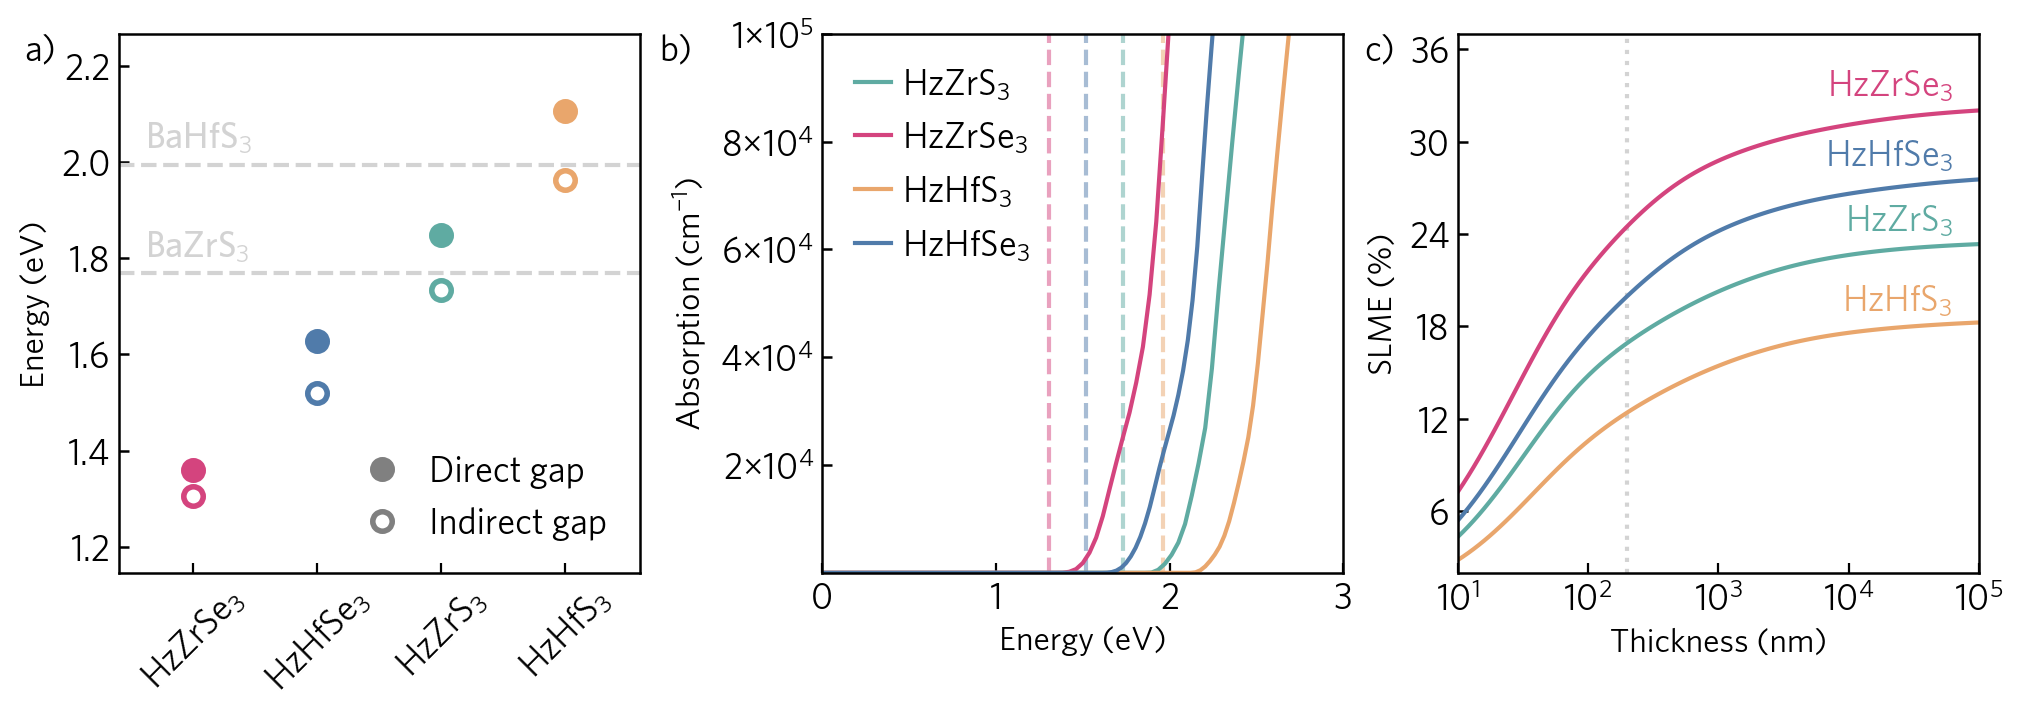

In [11]:

fig, (ax1, ax_space1, ax2, ax_space2, ax3) = plt.subplots(
    1,  5, 
    figsize=(12, 3.5), 
    gridspec_kw={"wspace": 0, "width_ratios": [1, 0.35, 1, 0.22, 1]}
)
ax_space1.set_visible(False)
ax_space2.set_visible(False)

plot_bandgap(ax1)
plot_absorption(ax2)
plot_slme(ax3)

ax1.text(-0.12, 1.0, 'a)', transform=ax1.transAxes, va='top', ha='right')
ax2.text(-0.25, 1.0, 'b)', transform=ax2.transAxes, va='top', ha='right')
ax3.text(-0.12, 1.0, 'c)', transform=ax3.transAxes, va='top', ha='right')

plt.savefig("../plots/optics_summary.pdf", dpi=400, bbox_inches='tight', pad_inches=0)


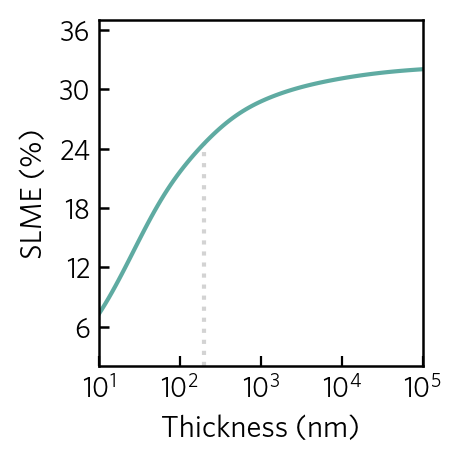

In [24]:
def plot_slme_one(system_name,absorption_data,figsize,label_fontsize,tick_fontsize):
    data = absorption_data[system_name]
    label = system_name.replace("3", "$_3$")

    fig, ax = plt.subplots(figsize=figsize)

    t = np.asarray(data["thickness_nm"])
    y = np.asarray(data["slme"])

    ax.plot(t, y, label=label)
    ax.set(
        xlabel="Thickness (nm)",
        ylabel="SLME (%)",
        xscale="log",
        xlim=(10, 1e5),
        ylim=(2, 37),
        xticks=([10, 100, 1000, 10000, 100000]),
        xticklabels=([r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$"])
    )
    
    ax.vlines(200, ymin=ax.get_ylim()[0], ymax=24.51, color="lightgray", linestyles=":", zorder=-5)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.xaxis.label.set_size(label_fontsize)
    ax.yaxis.label.set_size(label_fontsize)
    ax.tick_params(axis="x", labelsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_slme_one("HzZrSe3", absorption_data, figsize=(2.5, 2.5), label_fontsize=11, tick_fontsize=10)
plt.savefig("../plots/toc_slme.pdf", dpi=400, bbox_inches='tight')